# Quick start tutorial of how to use the SUIT toolbox for fMRI analysis
In this tutorial, you will learn how to use SUITPy, the Python implementation of the SUIT cerebellar toolbox, to perform a group fMRI analysis for the . We will walk through the essential steps:
* Isolating the cerebellum
* Normalizing volumes into SUIT space
* Reslicing contrast maps into SUIT space 
* Visualizing the results on the flat map 
* Summarizing the results using atlas ROI. 

To start you need: 
* An anatomical T1-weighted image of each subject (``sub-ex_T1w.nii.gz``) 
* The functional map(s) for each subject **coregistered** to the anatomical image (``sub-ex_contrast.nii.gz``)

We recommend to use a minimal processing pipeline, including only correction for spatial distortions, motion correction, and co=registration to the anatomical image. The first-level GLM is best calculated in the native space of the subject - normalization to MNI space or any smoothing is best avoided at this point. 

*Note: it is of course possible to apply the pipeline to MNI-normalized data, as long as both individual T1-images and functional maps are in MNI space. Smoothing should be avoided, however to prevent bleeding of cortical acvtivity into the cerebellum.*

*Note: You can find additional details and explanations for each step in the corresponding sections of the documentation.*


## Isolate the cerebellum


The first step is use ``isolate`` to create a cerebellum–brainstem mask from the anatomical image. The mask is required for normalization and helps avoid signal spillover from nearby cortex.

In [1]:
# Import necessary packages
from nilearn import plotting
import SUITPy as suit
import nibabel as nib

In [2]:
# This function generates isolation mask for the cerebellum based on a T1 scan
suit.isolate('sub-ex_T1w.nii.gz')

preprocessing
isolating cerebellum using UNet model
postprocessing
saving results into /Users/jdiedrichsen/Python/SUITPy/docs/source/tutorials


ANTsImage (RPI)
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (256, 320, 320)
	 Spacing    : (0.7, 0.7, 0.7)
	 Origin     : (-90.3, 124.6, -107.8)
	 Direction  : [ 1.  0.  0.  0. -1.  0.  0.  0.  1.]

 The mask is saved as ``sub-ex_T1w_cerebellum_dseg.nii.gz`` in the same folder as the anatomical scan.
 
 Although the isolation algorithm works very reliably and usually does not require and correction, it is good practice to check the mask.  

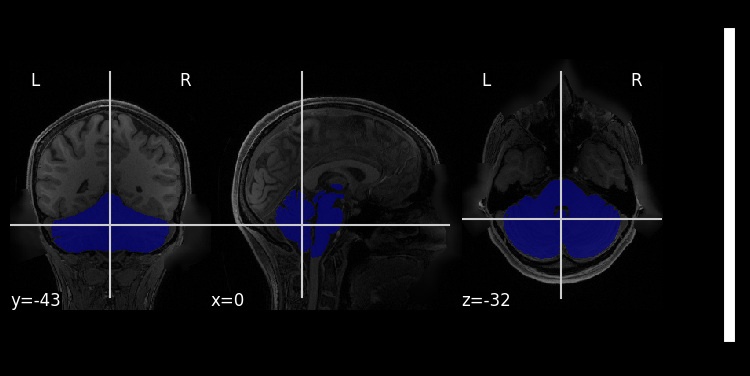

In [3]:
# Visualize the mask on the T1 image
img = nib.load('sub-ex_T1w.nii.gz')
mask = nib.load('sub-ex_T1w_cerebellum_dseg.nii.gz')
plotting.plot_roi(mask,img)

## Normalize the cerebellum to the SUIT template
The SUIT normalization module estimates a deformation field that aligns an individual’s cerebellum to the SUIT template, using the isolation mask from the previous step. In SUITPy, this procedure is implemented with ANTsPy (available from version 2.1). The resulting deformation can then be applied to reslice anatomical or functional data into SUIT space.

In the simplest usage, normalize requires only the subject’s T1-weighted image and the isolation mask.

In [5]:
# This function normalizes a source image to the SUIT cerebellar template using a provided cerebellum mask.
mytx = suit.normalize(source_file = 'sub-ex_T1w.nii.gz',
                 mask_file = 'sub-ex_T1w_cerebellum_dseg.nii.gz')

registering to template of /Users/jdiedrichsen/Python/SUITPy/SUITPy/templates/tpl-SUIT_T1w.nii.gz
Saving the forward transforms into /Users/jdiedrichsen/Python/SUITPy/docs/source/tutorials/sub-ex_T1w_xfm-SUIT_Composite.h5
Saving the normalized image into /Users/jdiedrichsen/Python/SUITPy/docs/source/tutorials
Saving the deformation field into /Users/jdiedrichsen/Python/SUITPy/docs/source/tutorials/sub-ex_T1w_from-SUIT_mode-point_xfm.nii.gz


This step generate the deformation field as ``sub-ex_T1w_xfm_SUIT_Composite.h5`` and ``sub-ex_T1w_to-SUIT_model-image_xfm.nii.gz``. 

The normalized image is saved as ``sub-ex_T1w_space-SUIT.nii.gz``. 

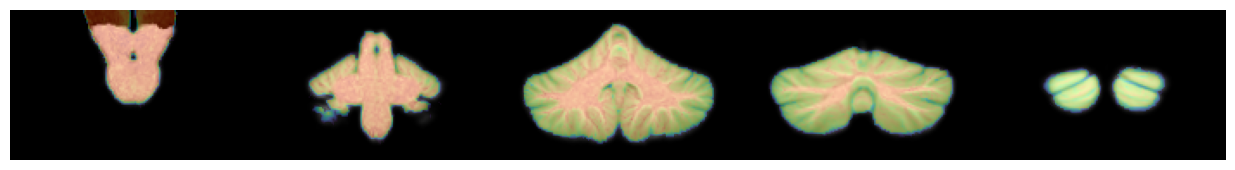

In [ ]:
# COMMENTL: I DON'T LIKE THAT YOU SUDDELY DEPEND ON ANTS TO PLOT - USE NILEARN TO PLOT THE TEMPLATE AND NORMALIZED IMAGE
import ants
w_anat_img = mytx['warpedmovout']
template_img = ants.image_read('/templates//tpl-SUIT_T1w.nii.gz')
ants.plot(template_img, overlay=w_anat_img, axis=1, nslices=5, overlay_alpha=0.4)

## Reslice functional data in SUIT space
Im the next step, you want to apply the deformation to the functional data.  


THIS NEEDS TO BE DONE WITH THE OUTPUT OF LAST Steps, USING the NEW ANTS NORMALIZATION 
This example shows the use of the function reslice_image. We assume you have produced an isolation mask and a deformation file (y_suitdef.nii) using the Matlab version (for detail information please refer to reslicing documentation).

In [ ]:
output_img = reslice.reslice_image(source_image = 'anatomical_sess-01.nii',
                                    deformation = 'y_suitdef.nii',
                                    mask = 'c_anatomical_sess-01_pcereb.nii')

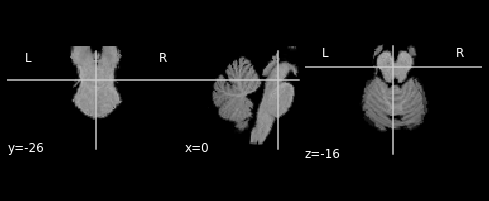

In [ ]:
plotting.plot_anat(output_img)

## Conduct group-analysis in SUIT space

REWRITE.... JOERN 
 
Once individual subjects have been isolated and normalized to SUIT space, group-level analyses can be carried out using any statistical framework (e.g., **FSL, SPM, .etc**). SUITPy’s role is to ensure that all cerebellar data are aligned to a common high-resolution template, so the group analysis itself is not restricted to a specific package.

In practice, group analysis in SUIT space typically involves:

* Normalizing each subject’s functional or statistical map (e.g., contrast estimate, t-map, beta map) into SUIT space using SUITPy’s normalization pipeline.

* Reslicing all subjects’ data to the same SUIT template grid using suit_reslice.

* Stacking the normalized volumes across subjects into a single subject list.

* Applying your preferred group-level model, such as:

  * one-sample / paired / independent-samples t-tests

  * GLMs with covariates (age, behavior, performance, etc.)

  * mixed-effects models for multi-session datasets

* Correcting for multiple comparisons (FDR, cluster-based correction, threshold-free cluster enhancement, etc.).

* Visualising the group results on the SUIT flatmap using suit_flatmap.plot_map.

SUITPy standardizes the cerebellar space and provides high-quality flatmaps; the statistical analysis itself can be performed with whichever neuroimaging or statistical tools best fit your pipeline.

## Viaulize on the flatmap

## Get altlas and summarize